In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import joblib

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df = pd.read_csv('startup.csv')
df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,6.2,6.5,15.2,3.4,4.2,2.2,2.6,1.0,Low,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,6.9,6.3,17.5,9.7,2.7,2.7,1.7,1.0,Low,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,4.0,5.4,4.8,5.7,5.6,7.7,9.0,5.8,Moderate,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,5.0,0.6,4.2,5.9,7.2,10.0,5.4,5.6,Moderate,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,5.2,2.5,9.2,5.4,5.6,6.5,3.4,4.6,Moderate,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  str    
 1   Economic_Climate                50000 non-null  str    
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  str    
 5   Funding_Stage                   50000 non-null  str    
 6   Work_Mode                       50000 non-null  str    
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             50000 non-n

In [4]:
pd.set_option('display.max_columns', None)
df.describe()

,Founder_Age,Founder_Experience_Years,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Shutdown_Probability,Startup_Failure_Flag
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.116580,2.62538,54.708660,72.630640,63.703472,5.690506,3.756374,9.256180,6.135680,4.012498,5.114294,4.506346,3.439614,0.107880,5.540454,12.392214,5.330516,35.855618,6.742784,0.386161,0.237340
std,6.503577,2.10280,112.424631,41.044886,13.160604,1.008238,1.298077,6.514507,2.223854,2.334365,2.502413,2.586042,2.229828,0.310232,14.459565,6.310302,2.406663,16.482813,2.745858,0.296182,0.425457
min,21.000000,0.00000,1.000000,2.000000,28.000000,2.800000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-45.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,1.00000,6.000000,37.000000,54.700000,5.000000,2.900000,4.100000,4.600000,2.300000,3.200000,2.300000,1.200000,0.000000,-3.500000,7.800000,3.600000,23.800000,4.700000,0.118000,0.000000
50%,34.000000,2.00000,16.000000,73.000000,63.600000,5.700000,3.700000,8.900000,6.200000,4.000000,5.100000,4.200000,3.100000,0.000000,4.000000,12.300000,5.300000,35.000000,7.100000,0.318000,0.000000
75%,39.000000,4.00000,54.000000,108.000000,72.600000,6.400000,4.600000,13.700000,7.800000,5.600000,6.900000,6.400000,5.000000,0.000000,14.500000,16.700000,7.100000,47.000000,9.300000,0.633000,0.000000
max,61.000000,12.00000,799.000000,143.000000,110.000000,9.000000,7.000000,35.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,74.700000,36.000000,10.000000,97.600000,10.000000,0.998000,1.000000


In [5]:
df.shape

(50000, 29)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [8]:
for i in df:
    print(df[i].value_counts())

Founder_Type
Solo Hustler               9010
Technical Builder          8998
Serial Entrepreneur        7045
Growth Obsessed Founder    7014
Visionary CEO              5056
Burned-Out Operator        4932
Chaotic Innovator          3987
Calm Operator              3958
Name: count, dtype: int64
Economic_Climate
Stable Economy    22416
Funding Winter    11128
Bull Market        9026
Recession          7430
Name: count, dtype: int64
Founder_Age
34    2968
32    2948
35    2945
36    2865
33    2859
31    2746
37    2682
38    2512
30    2496
29    2378
39    2246
40    2097
28    1981
41    1764
27    1718
26    1437
21    1429
42    1417
43    1174
25    1158
44     978
24     934
45     780
23     736
22     606
46     587
47     479
48     309
49     244
50     172
51     135
52      79
53      58
54      29
55      17
56      16
57      13
59       4
61       2
60       1
58       1
Name: count, dtype: int64
Founder_Experience_Years
1     11539
2     11044
3      7818
0      5974
4   

imbalancing : Economic_Climate , Founder_Age(binening) , Founder_Experience_Years ,

In [9]:
for i in df:
    print(df[i].value_counts()/float(len(df)))

Founder_Type
Solo Hustler               0.18020
Technical Builder          0.17996
Serial Entrepreneur        0.14090
Growth Obsessed Founder    0.14028
Visionary CEO              0.10112
Burned-Out Operator        0.09864
Chaotic Innovator          0.07974
Calm Operator              0.07916
Name: count, dtype: float64
Economic_Climate
Stable Economy    0.44832
Funding Winter    0.22256
Bull Market       0.18052
Recession         0.14860
Name: count, dtype: float64
Founder_Age
34    0.05936
32    0.05896
35    0.05890
36    0.05730
33    0.05718
31    0.05492
37    0.05364
38    0.05024
30    0.04992
29    0.04756
39    0.04492
40    0.04194
28    0.03962
41    0.03528
27    0.03436
26    0.02874
21    0.02858
42    0.02834
43    0.02348
25    0.02316
44    0.01956
24    0.01868
45    0.01560
23    0.01472
22    0.01212
46    0.01174
47    0.00958
48    0.00618
49    0.00488
50    0.00344
51    0.00270
52    0.00158
53    0.00116
54    0.00058
55    0.00034
56    0.00032
57    0.00026


In [10]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols

Index(['Founder_Age', 'Founder_Experience_Years', 'Team_Size',
       'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken',
       'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Founder_Burnout_Flag',
       'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining',
       'Product_Market_Fit_Score', 'Employee_Turnover_Percent',
       'Work_Life_Balance_Score', 'Shutdown_Probability',
       'Startup_Failure_Flag'],
      dtype='str')

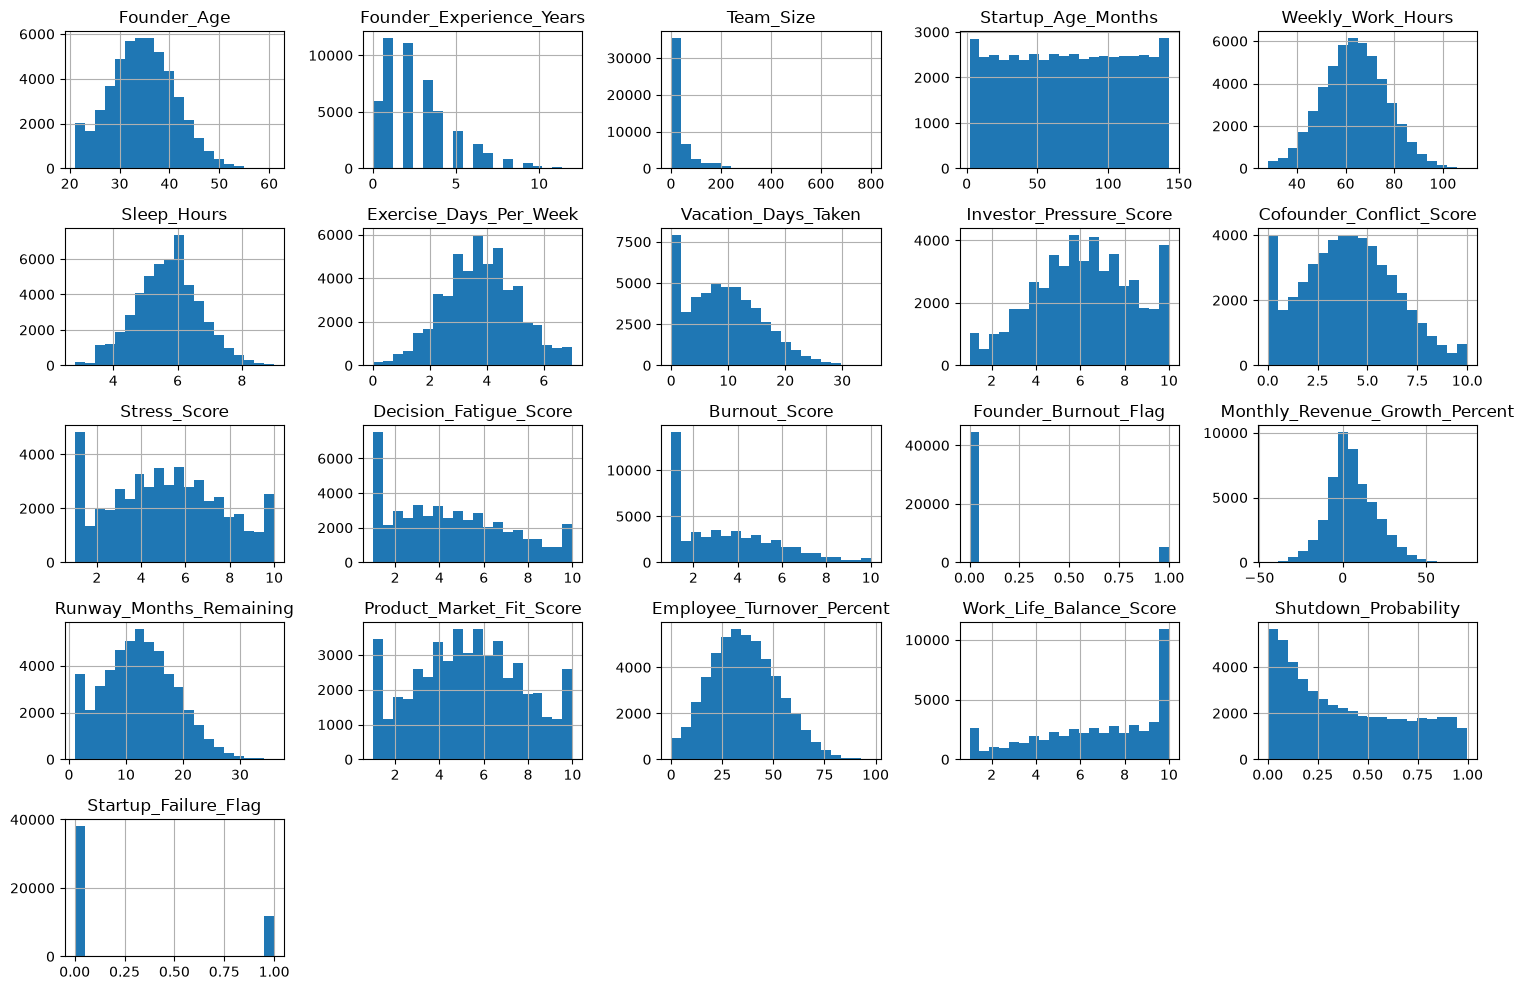

In [11]:
df[numeric_cols].hist(figsize=(15, 10), bins=20)

plt.tight_layout()
plt.show()

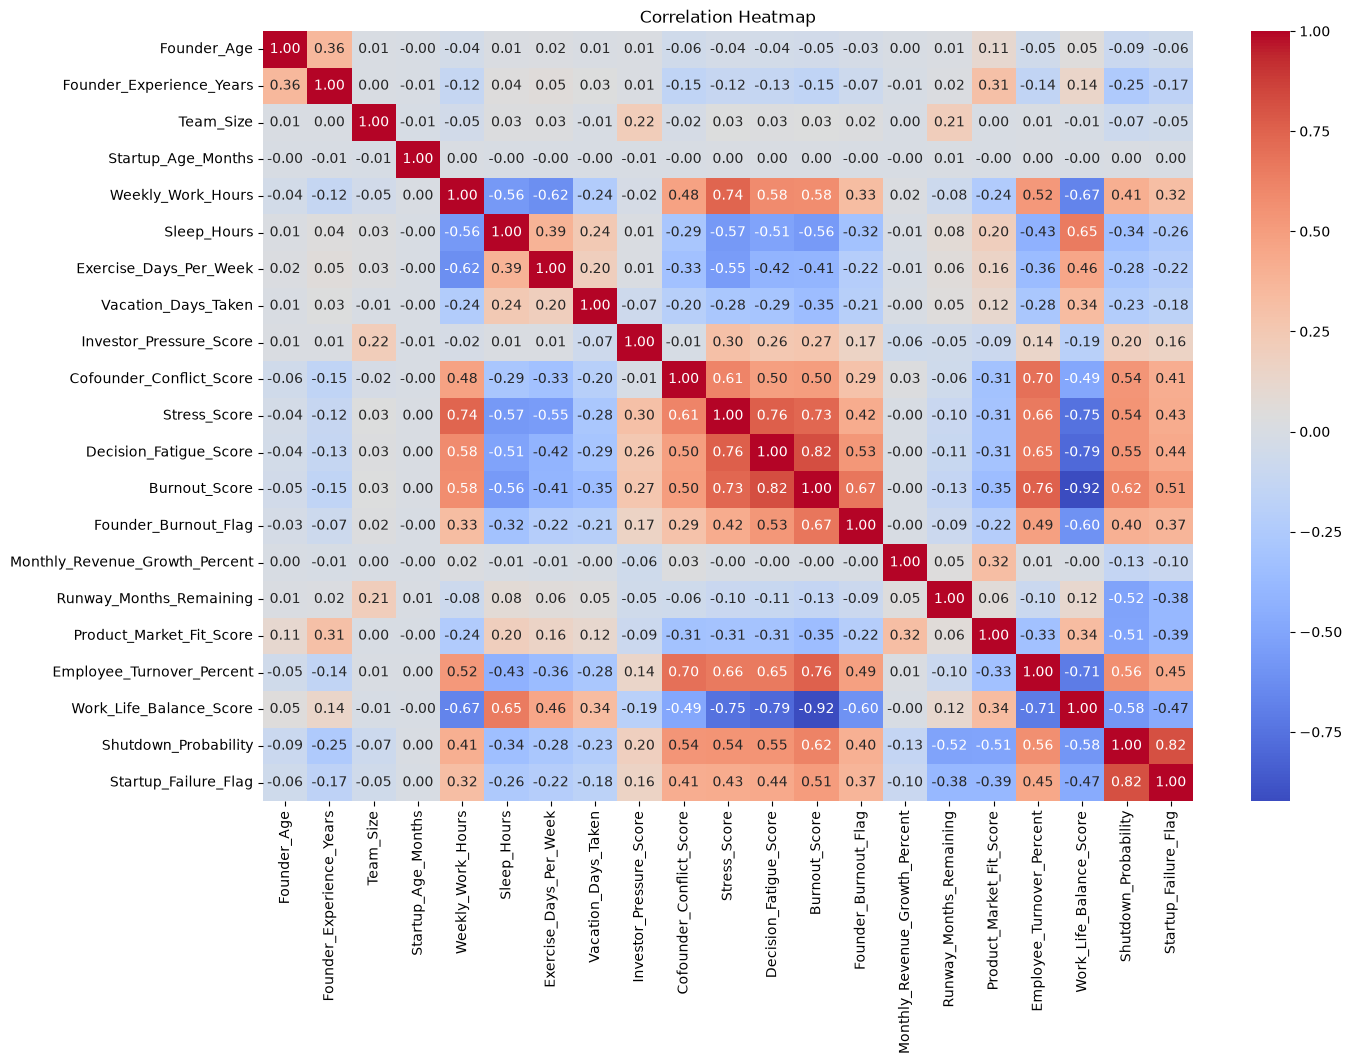

In [12]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

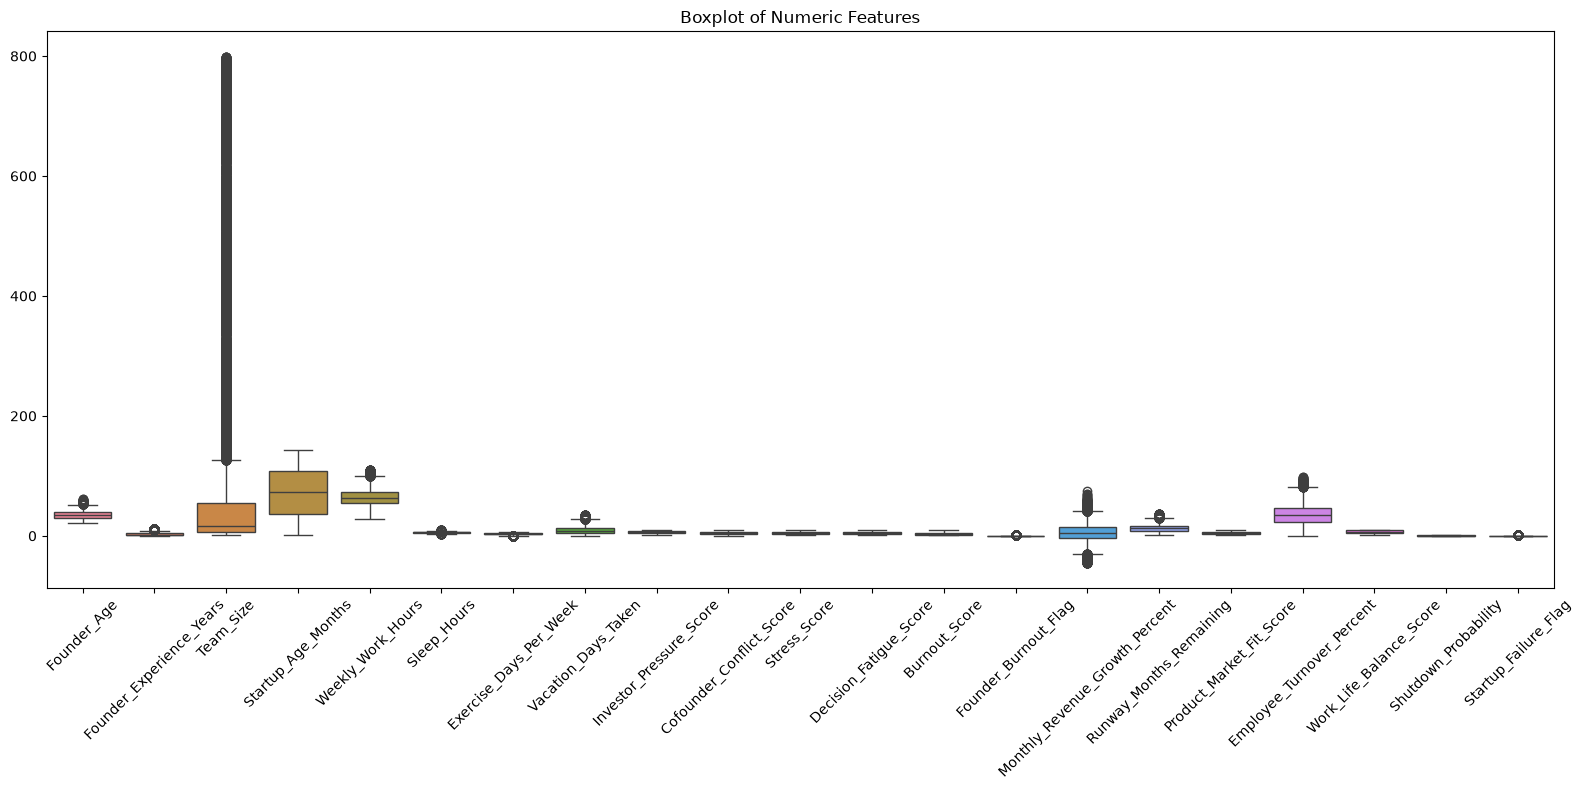

In [13]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title('Boxplot of Numeric Features')
plt.tight_layout()
plt.show()

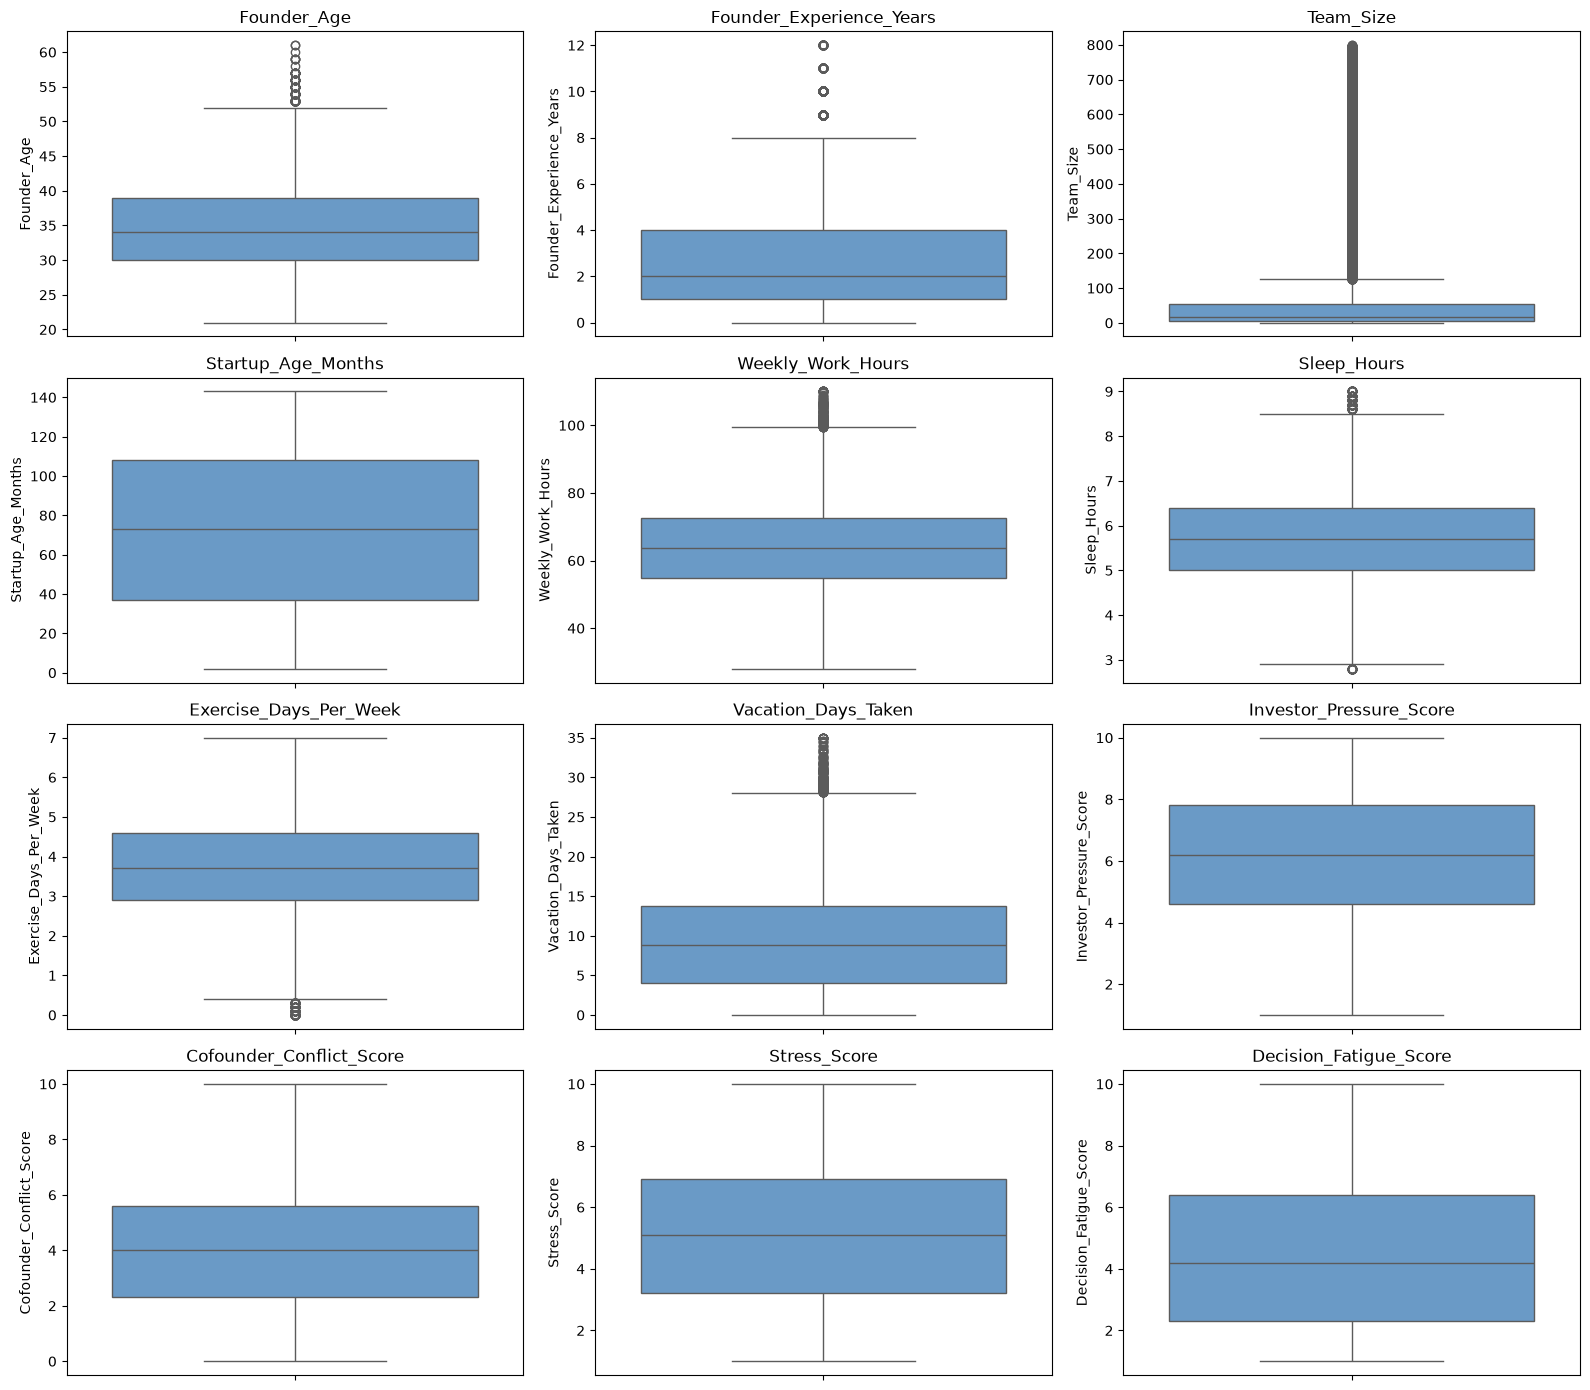

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:12]):
    sns.boxplot(y=df[col], ax=axes[i], color="#5b9bd5")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [15]:
numeric_cols

Index(['Founder_Age', 'Founder_Experience_Years', 'Team_Size',
       'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken',
       'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Founder_Burnout_Flag',
       'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining',
       'Product_Market_Fit_Score', 'Employee_Turnover_Percent',
       'Work_Life_Balance_Score', 'Shutdown_Probability',
       'Startup_Failure_Flag'],
      dtype='str')

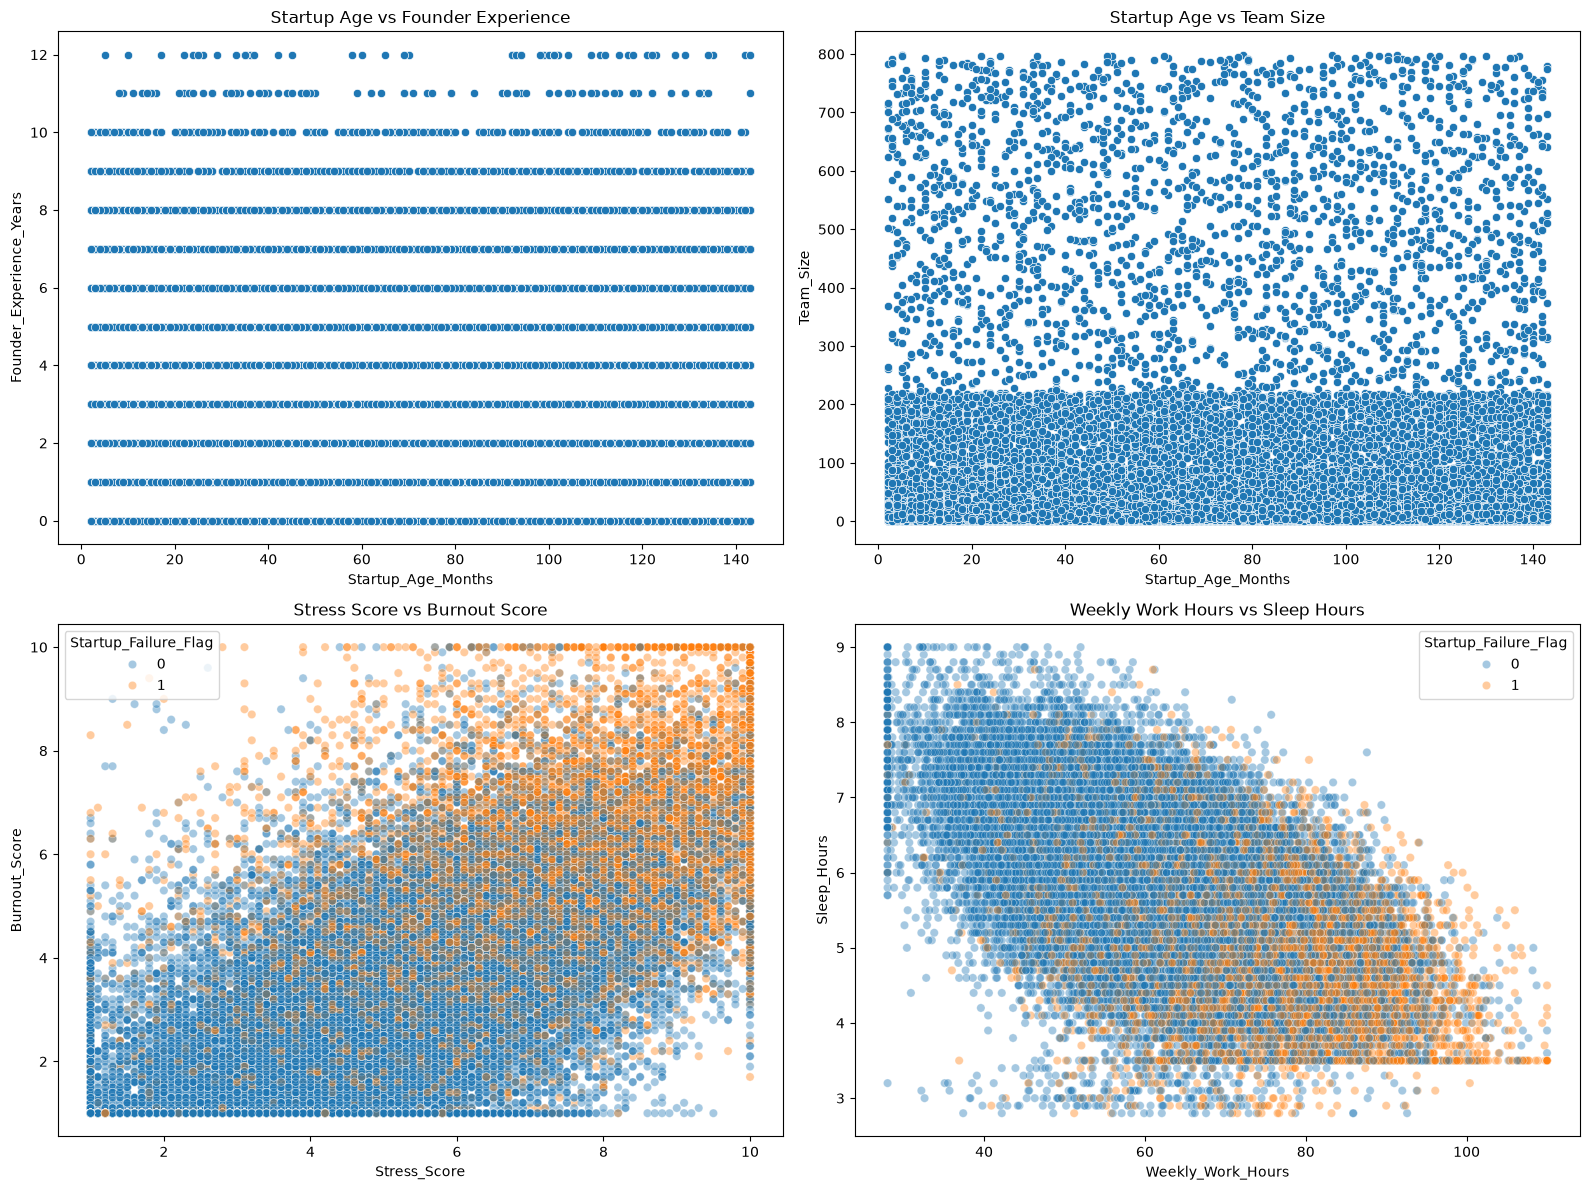

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(data=df, x='Startup_Age_Months', y='Founder_Experience_Years', ax=axes[0, 0])
axes[0, 0].set_title('Startup Age vs Founder Experience')

sns.scatterplot(data=df, x='Startup_Age_Months', y='Team_Size', ax=axes[0, 1])
axes[0, 1].set_title('Startup Age vs Team Size')

sns.scatterplot(data=df, x='Stress_Score', y='Burnout_Score', hue=df['Startup_Failure_Flag'], alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title('Stress Score vs Burnout Score')

sns.scatterplot(data=df, x='Weekly_Work_Hours', y='Sleep_Hours', hue=df['Startup_Failure_Flag'], alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Weekly Work Hours vs Sleep Hours')

plt.tight_layout()
plt.show()

In [17]:
df = df.drop(columns=['Shutdown_Probability'])
numeric_cols = numeric_cols.drop('Shutdown_Probability')

no relation between Startup_Age_Months , Founder_Age
no relation between Startup_Age_Months , Founder_Experience
team_size > 200 (large company) , team_size <= 200 (small company)

In [18]:
categoric_cols = df.select_dtypes(include=['string' , 'object']).columns
categoric_cols

Index(['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage',
       'Work_Mode', 'Burnout_Level', 'Seeks_Mental_Health_Support',
       'Shutdown_Risk'],
      dtype='str')

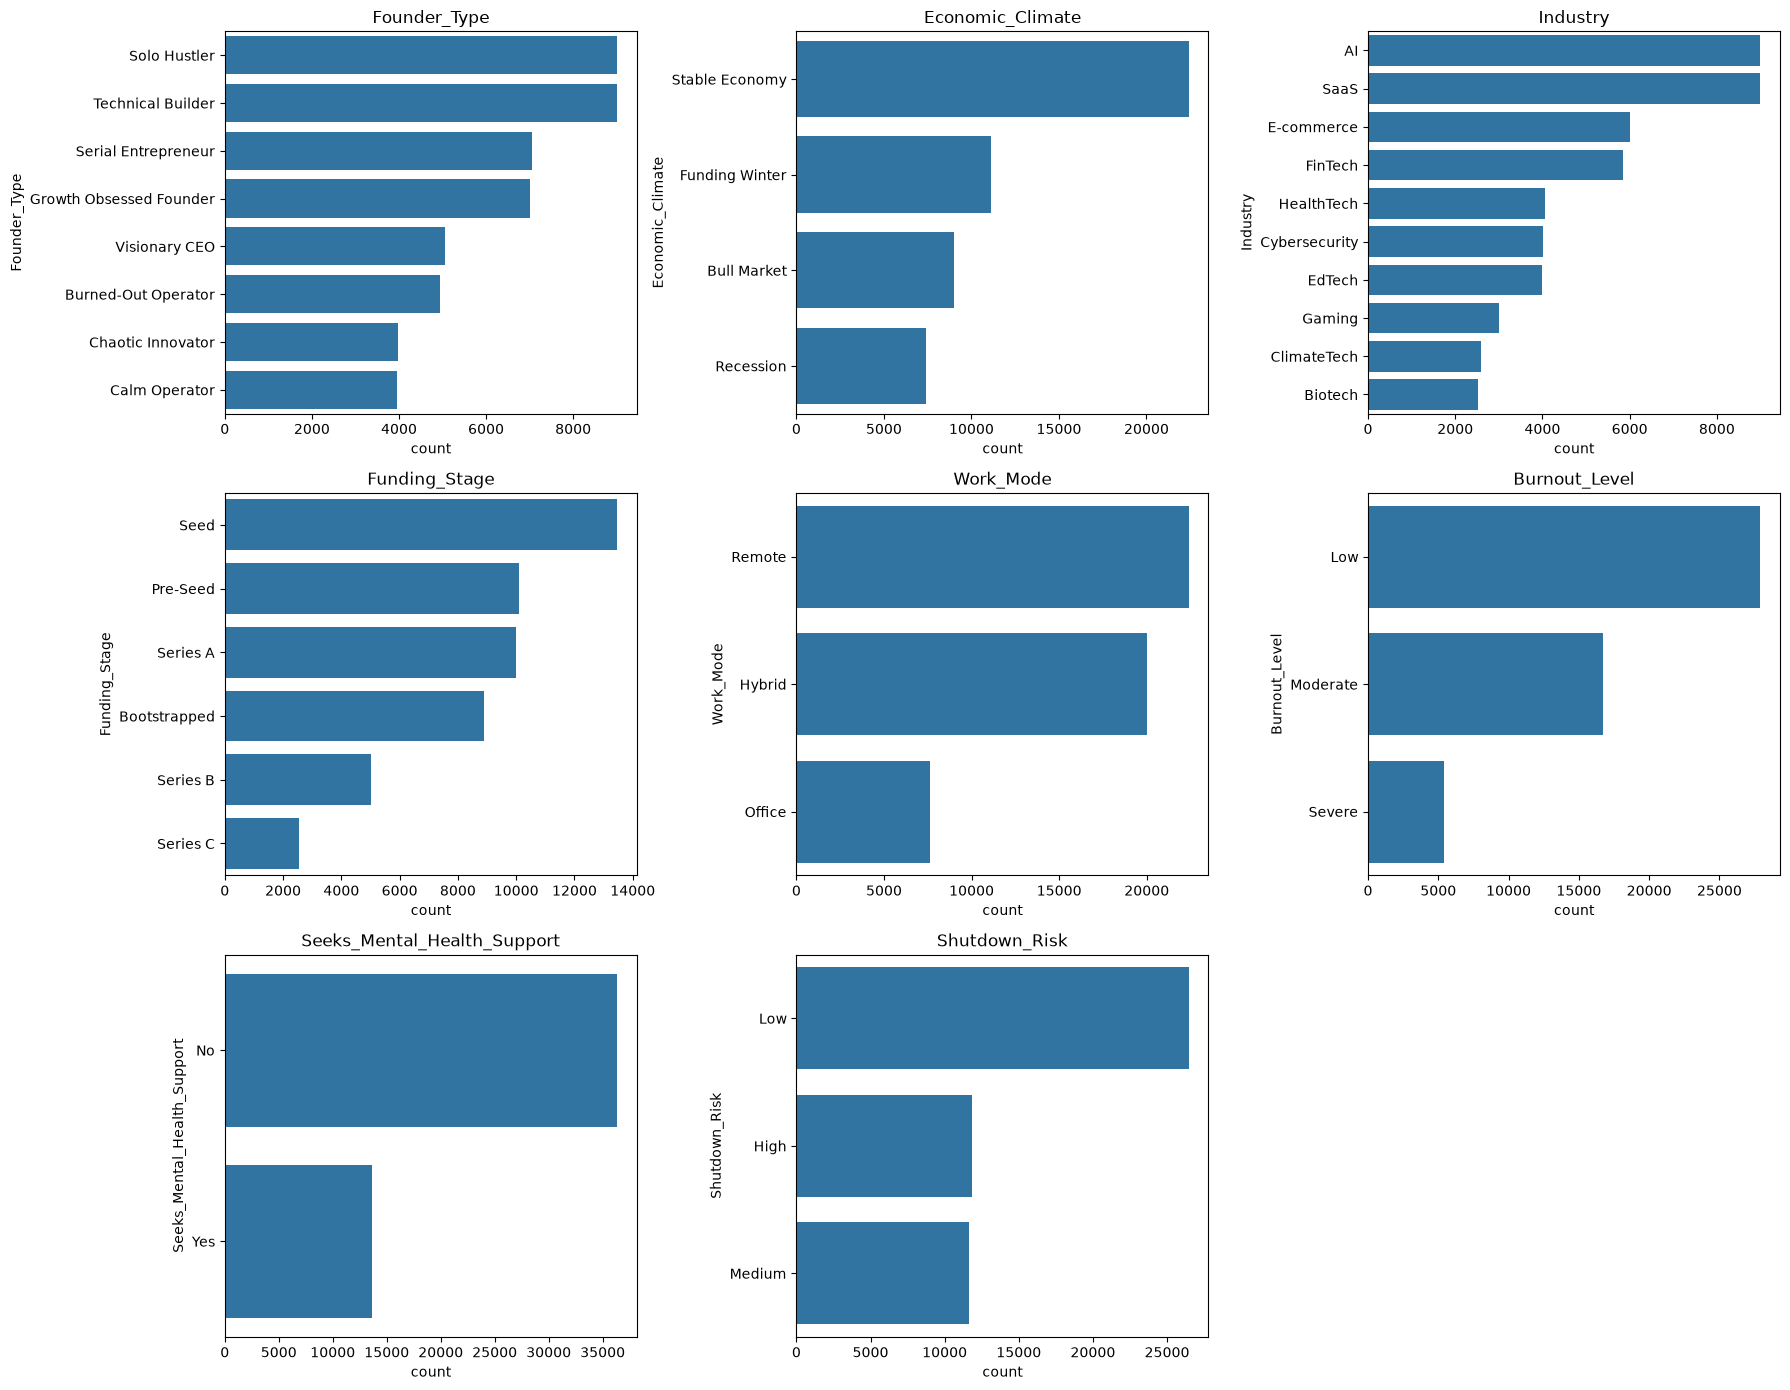

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(categoric_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
for j in range(len(categoric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

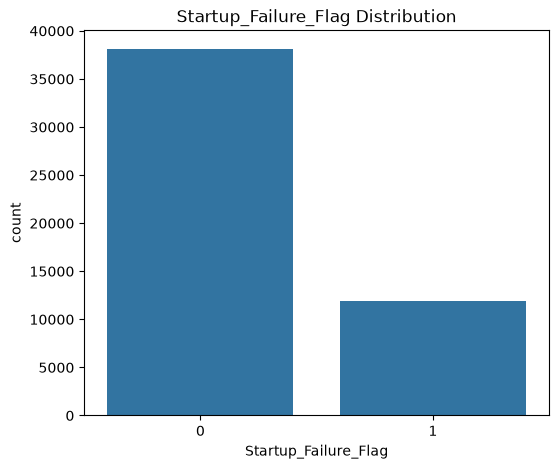

Startup_Failure_Flag
0    0.76266
1    0.23734
Name: proportion, dtype: float64

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df['Startup_Failure_Flag'])
plt.title('Startup_Failure_Flag Distribution')
plt.show()

df['Startup_Failure_Flag'].value_counts(normalize=True)

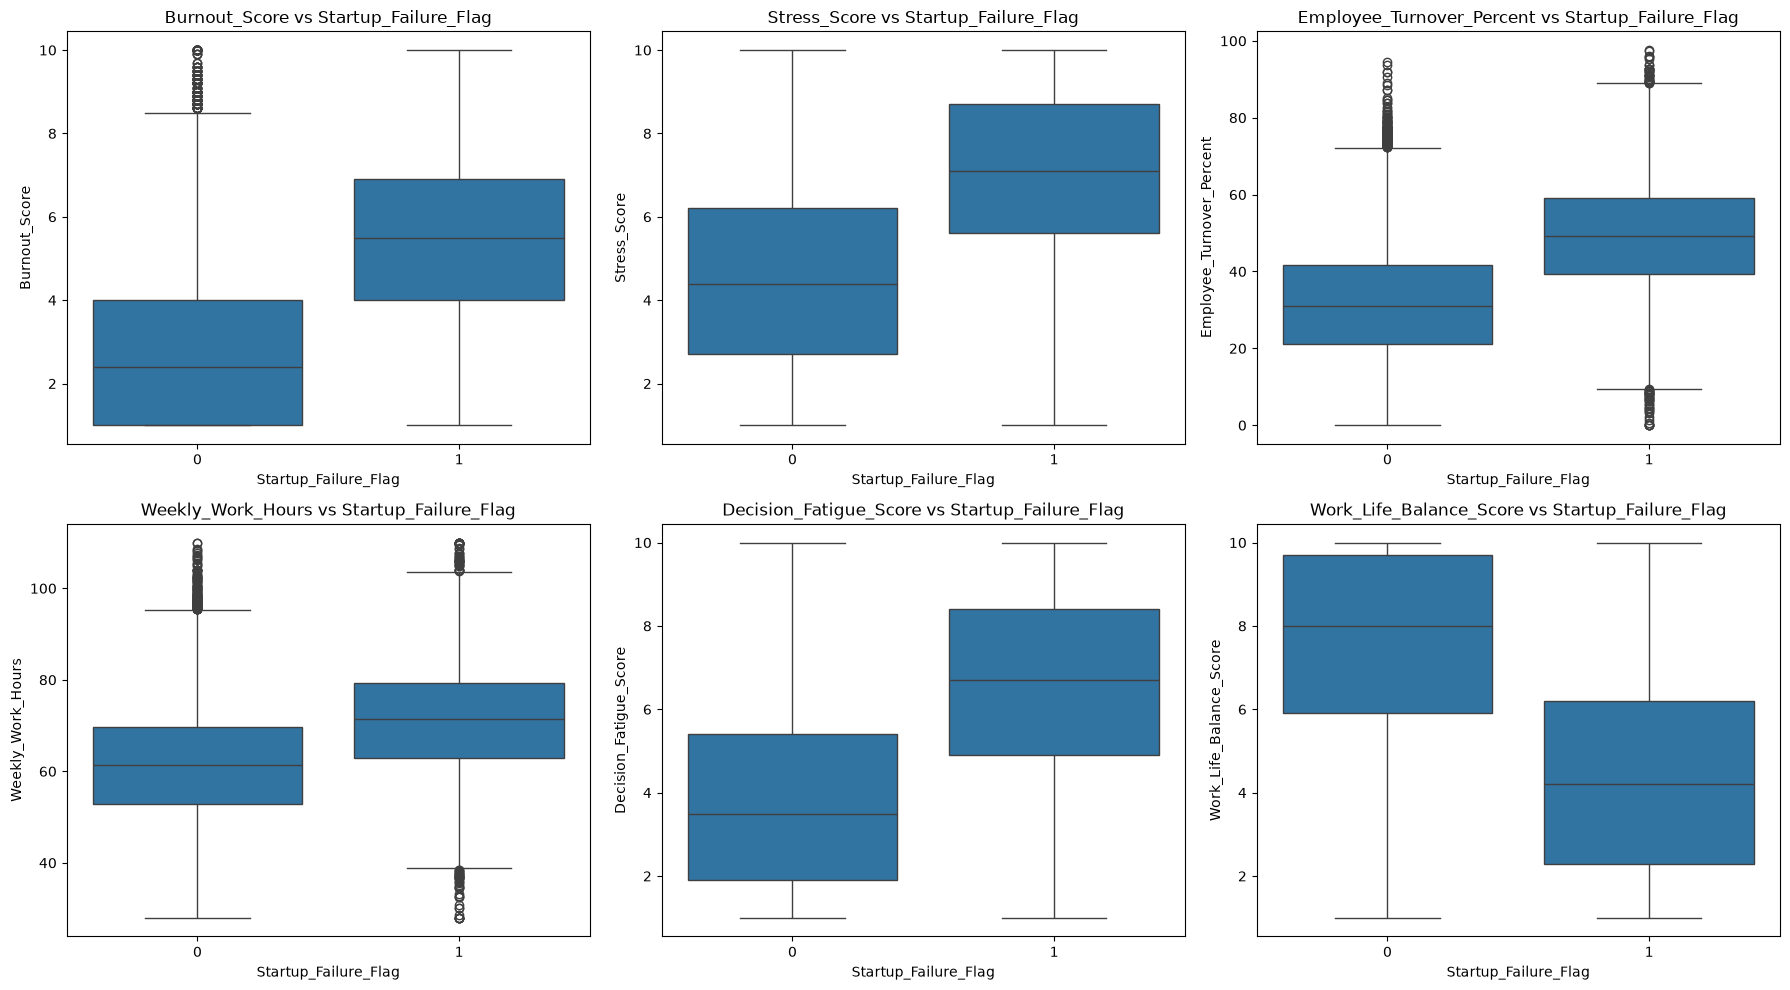

In [21]:
target_related_cols = ['Burnout_Score', 'Stress_Score', 'Employee_Turnover_Percent',
                        'Weekly_Work_Hours', 'Decision_Fatigue_Score', 'Work_Life_Balance_Score']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(target_related_cols):
    sns.boxplot(x=df['Startup_Failure_Flag'], y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} vs Startup_Failure_Flag')
plt.tight_layout()
plt.show()

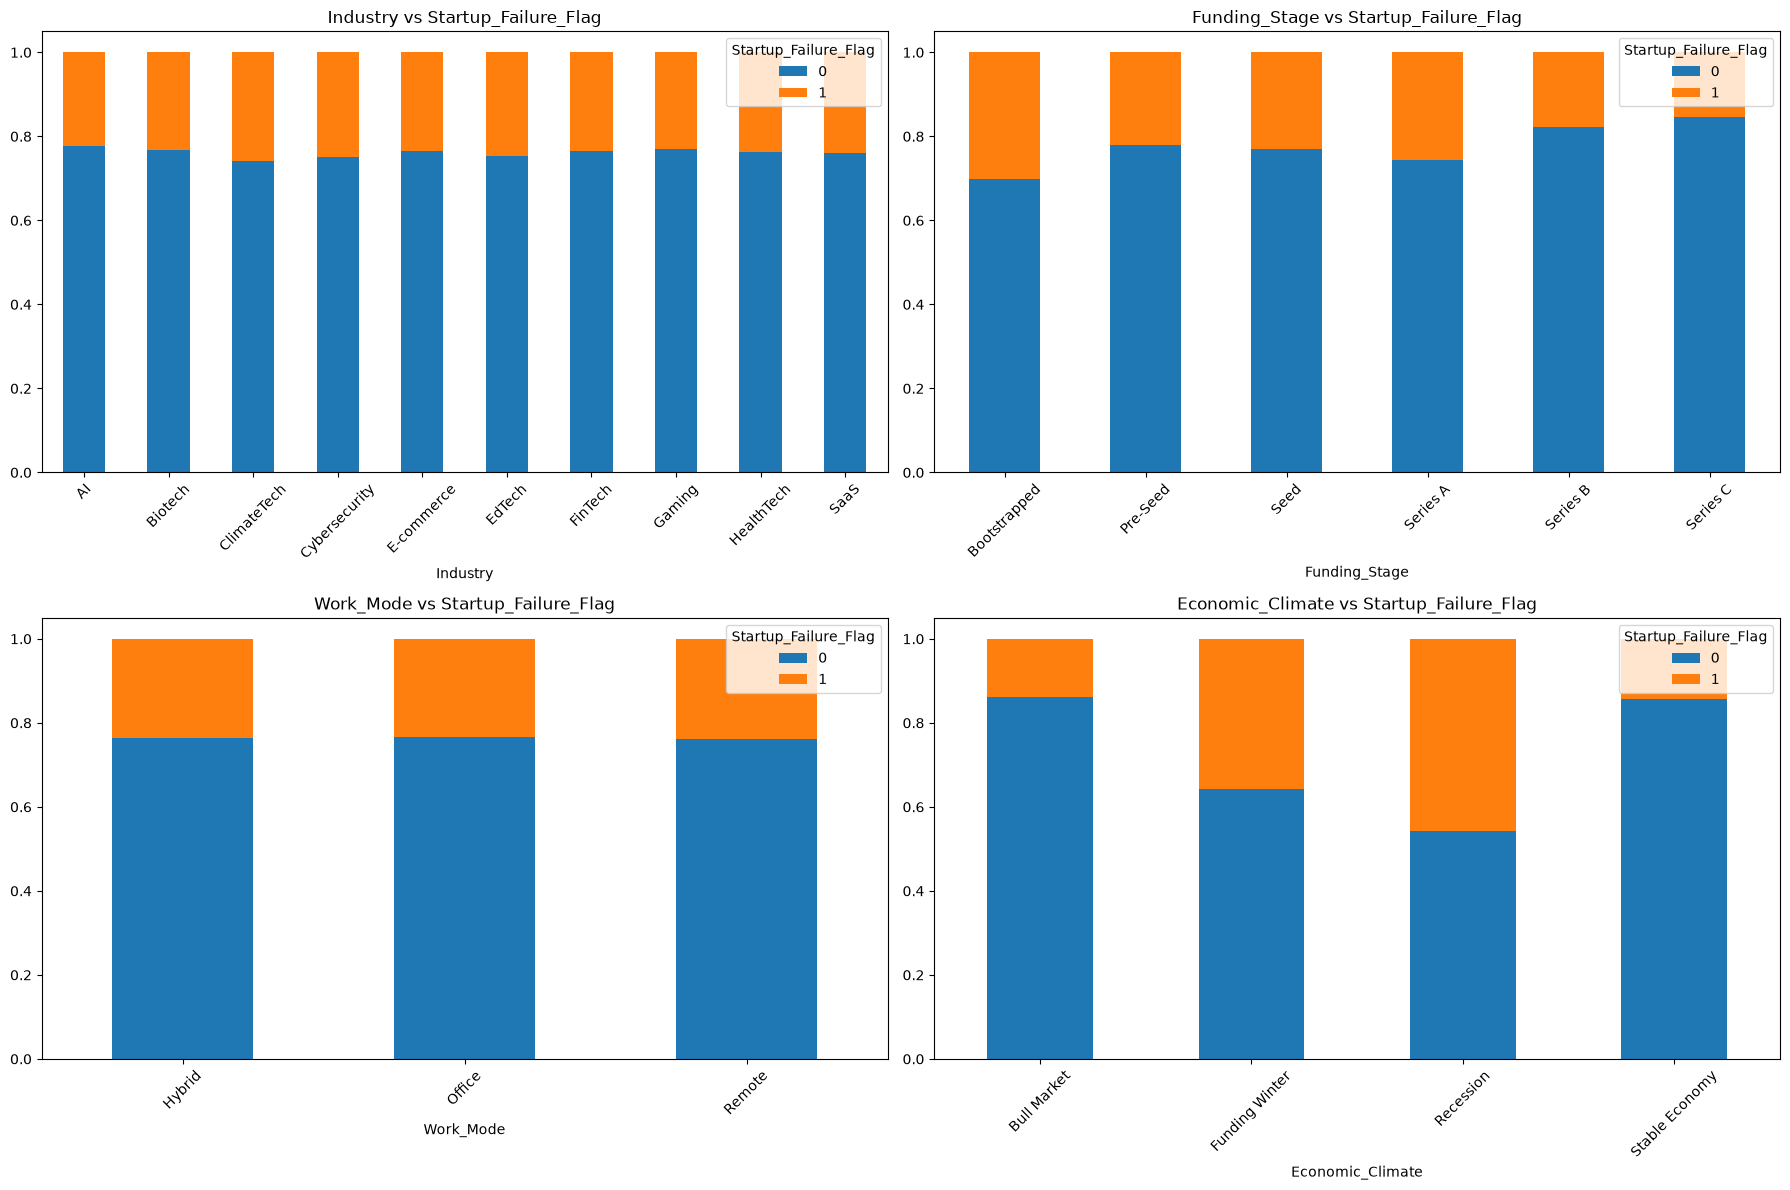

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(['Industry', 'Funding_Stage', 'Work_Mode', 'Economic_Climate']):
    ct = pd.crosstab(df[col], df['Startup_Failure_Flag'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs Startup_Failure_Flag')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [23]:
q1 = df['Team_Size'].quantile(0.25)
q3 = df['Team_Size'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
lower = max(lower, df['Team_Size'].min())

df['Team_Size'] = df['Team_Size'].clip(lower=lower, upper=upper)
df['Team_Size'].describe()

count    50000.000000
mean        35.074720
std         40.076219
min          1.000000
25%          6.000000
50%         16.000000
75%         54.000000
max        126.000000
Name: Team_Size, dtype: float64

eda_summary = """
EDA Summary:
1. Shutdown_Probability was removed (0.82 correlation with target = data leakage)
2. Team_Size had real outliers up to 800, capped using IQR
3. Startup_Failure_Flag is imbalanced (~76% / 24%)
4. Stress_Score, Decision_Fatigue_Score, Burnout_Score, Work_Life_Balance_Score,
   Employee_Turnover_Percent are highly correlated with each other (multicollinearity)
5. Most correlated features with target: Burnout_Score, Employee_Turnover_Percent,
   Decision_Fatigue_Score, Stress_Score
"""
print(eda_summary)

In [24]:
pd.set_option('display.max_columns', None)
df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,6.2,6.5,15.2,3.4,4.2,2.2,2.6,1.0,Low,0,-5.1,5.6,7.8,30.0,9.7,No,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,6.9,6.3,17.5,9.7,2.7,2.7,1.7,1.0,Low,0,2.7,8.4,2.3,14.4,10.0,No,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,4.0,5.4,4.8,5.7,5.6,7.7,9.0,5.8,Moderate,0,16.3,4.4,1.0,41.5,4.0,No,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,5.0,0.6,4.2,5.9,7.2,10.0,5.4,5.6,Moderate,0,-1.4,31.5,4.0,39.4,5.1,No,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,5.2,2.5,9.2,5.4,5.6,6.5,3.4,4.6,Moderate,0,21.6,7.0,5.2,36.5,4.2,No,High,1


In [25]:
df.shape

(50000, 28)

In [26]:
corr_with_target = df.corr(numeric_only=True)['Startup_Failure_Flag'].abs().sort_values(ascending=False)
corr_with_target.head(10)

Startup_Failure_Flag         1.000000
Burnout_Score                0.506236
Work_Life_Balance_Score      0.470785
Employee_Turnover_Percent    0.449765
Decision_Fatigue_Score       0.439155
Stress_Score                 0.425410
Cofounder_Conflict_Score     0.414529
Product_Market_Fit_Score     0.386984
Runway_Months_Remaining      0.384222
Founder_Burnout_Flag         0.370003
Name: Startup_Failure_Flag, dtype: float64

In [27]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Startup_Failure_Flag', axis=1), df['Startup_Failure_Flag'], test_size=0.2, random_state=42)

In [28]:
numeric_cols = (
    x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
)

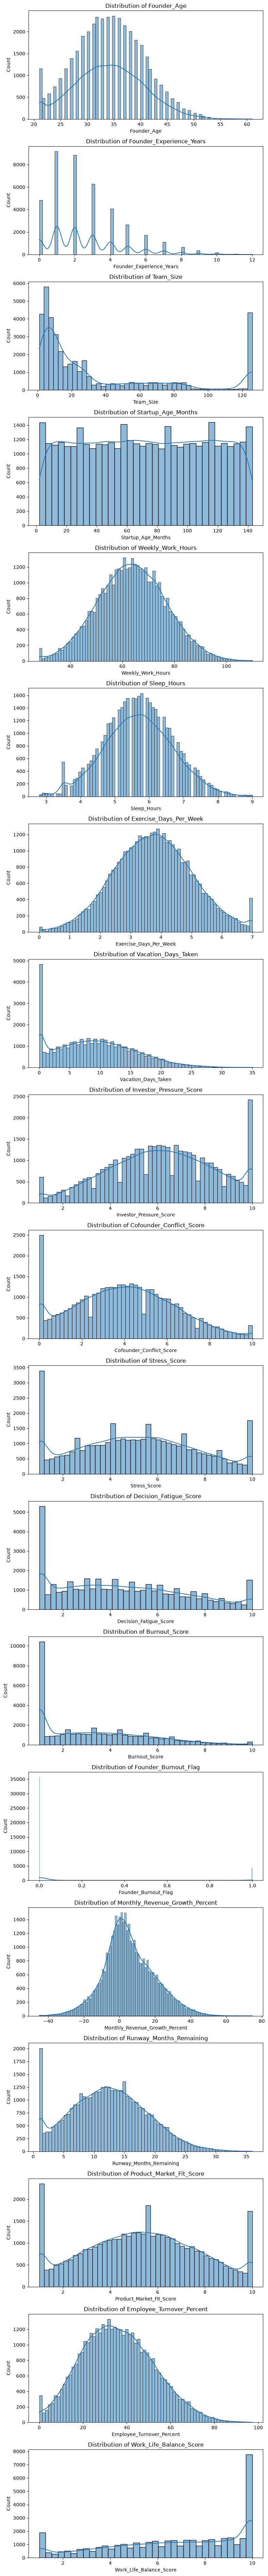

In [29]:
n_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(8, 4 * n_cols))

if n_cols == 1:
  axes = [axes]

for ax, col in zip(axes, numeric_cols):
  sns.histplot(data=x_train, x=col, kde=True, ax=ax)
  ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [30]:
skewness = x_train[numeric_cols].skew()
print(skewness)

Founder_Age                       0.148387
Founder_Experience_Years          1.119948
Team_Size                         1.301607
Startup_Age_Months               -0.004863
Weekly_Work_Hours                 0.046991
Sleep_Hours                       0.040493
Exercise_Days_Per_Week            0.053843
Vacation_Days_Taken               0.444847
Investor_Pressure_Score          -0.134959
Cofounder_Conflict_Score          0.182245
Stress_Score                      0.108821
Decision_Fatigue_Score            0.386260
Burnout_Score                     0.693885
Founder_Burnout_Flag              2.522687
Monthly_Revenue_Growth_Percent    0.261054
Runway_Months_Remaining           0.208502
Product_Market_Fit_Score          0.043783
Employee_Turnover_Percent         0.260564
Work_Life_Balance_Score          -0.503801
dtype: float64


In [31]:
print(x_train.shape, x_test.shape)

(40000, 27) (10000, 27)


In [32]:
print(y_train.value_counts(normalize=True))

Startup_Failure_Flag
0    0.76195
1    0.23805
Name: proportion, dtype: float64


In [33]:
X = df.drop(columns=['Startup_Failure_Flag',  'Shutdown_Risk'])
y = df['Startup_Failure_Flag']

In [34]:
X = pd.get_dummies(X, drop_first=True, dtype=float)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
skewed_cols = ['Founder_Experience_Years', 'Team_Size']
x_train[skewed_cols] = np.log1p(x_train[skewed_cols])
x_test[skewed_cols] = np.log1p(x_test[skewed_cols])

In [37]:
num_cols_to_scale = [
    'Founder_Age', 'Founder_Experience_Years', 'Team_Size', 'Startup_Age_Months',
    'Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week', 'Vacation_Days_Taken',
    'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
    'Decision_Fatigue_Score', 'Burnout_Score', 'Monthly_Revenue_Growth_Percent',
    'Runway_Months_Remaining', 'Product_Market_Fit_Score', 'Employee_Turnover_Percent',
    'Work_Life_Balance_Score'
]

In [38]:
scaler = RobustScaler()
x_train[num_cols_to_scale] = scaler.fit_transform(x_train[num_cols_to_scale])
x_test[num_cols_to_scale] = scaler.transform(x_test[num_cols_to_scale])

In [39]:
smt = SMOTETomek(random_state=42)
x_train_smt, y_train_smt = smt.fit_resample(x_train, y_train)

print("--- توزيع الفئات بعد SMOTE + Tomek Links ---")
print(y_train_smt.value_counts())

--- توزيع الفئات بعد SMOTE + Tomek Links ---
Startup_Failure_Flag
0    30458
1    30458
Name: count, dtype: int64


In [40]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}

In [41]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(x_train_smt, y_train_smt)
    y_pred = model.predict(x_test)
    predictions[name] = y_pred

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = model.decision_function(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n=== مقارنة أداء جميع النماذج بعد معالجة SMOTE + Tomek Links ===")
print(results_df.to_string(index=False))


=== مقارنة أداء جميع النماذج بعد معالجة SMOTE + Tomek Links ===
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            AdaBoost    0.8820     0.7227  0.8158    0.7664   0.9447
 Logistic Regression    0.8725     0.6807  0.8715    0.7644   0.9489
   Gradient Boosting    0.8801     0.7185  0.8133    0.7630   0.9459
       Random Forest    0.8811     0.7370  0.7758    0.7559   0.9380
             XGBoost    0.8821     0.7558  0.7434    0.7495   0.9422
Neural Network (MLP)    0.8648     0.6806  0.8108    0.7400   0.9323
       Decision Tree    0.8346     0.6141  0.8154    0.7006   0.9099
 K-Nearest Neighbors    0.7822     0.5246  0.8778    0.6567   0.8793


In [42]:
metrics_summary = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    rec_major = recall_score(y_test, y_pred, pos_label=0)  # Class 0 (Major)
    rec_minor = recall_score(y_test, y_pred, pos_label=1)  # Class 1 (Minor)

    prec_minor = precision_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    f1_minor = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    acc = accuracy_score(y_test, y_pred)

    metrics_summary.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Recall (Major - 0)": rec_major,
            "Recall (Minor - 1)": rec_minor,
            "Precision (Minor - 1)": prec_minor,
            "F1 (Minor - 1)": f1_minor,
            "ROC-AUC": roc,
        }
    )


In [43]:
summary_df = pd.DataFrame(metrics_summary)
summary_df = summary_df.sort_values(
    by="Recall (Minor - 1)", ascending=False
).reset_index(drop=True)

display(
    summary_df.style.highlight_max(
         subset=summary_df.columns[1:]
    ).format(
        {
            "Accuracy": "{:.3f}",
            "Recall (Major - 0)": "{:.3f}",
            "Recall (Minor - 1)": "{:.3f}",
            "Precision (Minor - 1)": "{:.3f}",
            "F1 (Minor - 1)": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

,Model,Accuracy,Recall (Major - 0),Recall (Minor - 1),Precision (Minor - 1),F1 (Minor - 1),ROC-AUC
0,Neural Network (MLP),0.890,0.931,0.758,0.774,0.766,0.948
1,AdaBoost,0.889,0.939,0.731,0.788,0.758,0.946
2,Logistic Regression,0.890,0.939,0.730,0.789,0.759,0.949
3,XGBoost,0.886,0.935,0.729,0.777,0.752,0.942
4,Gradient Boosting,0.892,0.944,0.724,0.802,0.761,0.948
5,Decision Tree,0.865,0.928,0.662,0.741,0.699,0.909
6,Random Forest,0.882,0.951,0.661,0.809,0.728,0.938
7,K-Nearest Neighbors,0.860,0.933,0.624,0.745,0.679,0.883


In [44]:
display(
    summary_df.style.format(
        {
            "Accuracy": "{:.3f}",
            "Recall (Major - 0)": "{:.3f}",
            "Recall (Minor - 1)": "{:.3f}",
            "Precision (Minor - 1)": "{:.3f}",
            "F1 (Minor - 1)": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

,Model,Accuracy,Recall (Major - 0),Recall (Minor - 1),Precision (Minor - 1),F1 (Minor - 1),ROC-AUC
0,Neural Network (MLP),0.890,0.931,0.758,0.774,0.766,0.948
1,AdaBoost,0.889,0.939,0.731,0.788,0.758,0.946
2,Logistic Regression,0.890,0.939,0.730,0.789,0.759,0.949
3,XGBoost,0.886,0.935,0.729,0.777,0.752,0.942
4,Gradient Boosting,0.892,0.944,0.724,0.802,0.761,0.948
5,Decision Tree,0.865,0.928,0.662,0.741,0.699,0.909
6,Random Forest,0.882,0.951,0.661,0.809,0.728,0.938
7,K-Nearest Neighbors,0.860,0.933,0.624,0.745,0.679,0.883


In [45]:
train_metrics_list = []

for name, model in models.items():
    y_train_pred = model.predict(x_train)

    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(x_train)[:, 1]
        roc_auc_train = roc_auc_score(y_train, y_train_prob)
    else:
        roc_auc_train = None

    train_metrics_list.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_train, y_train_pred),
            "Precision": precision_score(y_train, y_train_pred, zero_division=0),
            "Recall": recall_score(y_train, y_train_pred, zero_division=0),
            "F1-Score": f1_score(y_train, y_train_pred, zero_division=0),
            "ROC-AUC": roc_auc_train,
        }
    )

In [46]:
train_metrics_df = pd.DataFrame(train_metrics_list)
train_metrics_df = train_metrics_df.sort_values(
    by="F1-Score", ascending=False
).reset_index(drop=True)

print("=" * 65)
print("             TRAINING CLASSIFICATION METRICS COMPARISON             ")
print("=" * 65)
display(
    summary_df.style.format(
        {
            "Accuracy": "{:.3f}",
            "Recall (Major - 0)": "{:.3f}",
            "Recall (Minor - 1)": "{:.3f}",
            "Precision (Minor - 1)": "{:.3f}",
            "F1 (Minor - 1)": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

             TRAINING CLASSIFICATION METRICS COMPARISON             


,Model,Accuracy,Recall (Major - 0),Recall (Minor - 1),Precision (Minor - 1),F1 (Minor - 1),ROC-AUC
0,Neural Network (MLP),0.890,0.931,0.758,0.774,0.766,0.948
1,AdaBoost,0.889,0.939,0.731,0.788,0.758,0.946
2,Logistic Regression,0.890,0.939,0.730,0.789,0.759,0.949
3,XGBoost,0.886,0.935,0.729,0.777,0.752,0.942
4,Gradient Boosting,0.892,0.944,0.724,0.802,0.761,0.948
5,Decision Tree,0.865,0.928,0.662,0.741,0.699,0.909
6,Random Forest,0.882,0.951,0.661,0.809,0.728,0.938
7,K-Nearest Neighbors,0.860,0.933,0.624,0.745,0.679,0.883


In [59]:
train_metrics_list = []

for name, model in models.items():
    y_train_pred = model.predict(x_train)

    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(x_train)[:, 1]
        roc_auc_train = roc_auc_score(y_train, y_train_prob)
    else:
        roc_auc_train = None

    train_metrics_list.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_train, y_train_pred),
            "Precision": precision_score(y_train, y_train_pred, zero_division=0),
            "Recall": recall_score(y_train, y_train_pred, zero_division=0),
            "F1-Score": f1_score(y_train, y_train_pred, zero_division=0),
            "ROC-AUC": roc_auc_train,
        }
    )

train_metrics_df = pd.DataFrame(train_metrics_list)
train_metrics_df = train_metrics_df.sort_values(
    by="F1-Score", ascending=False
).reset_index(drop=True)

print("=" * 65)
print("             TRAINING CLASSIFICATION METRICS COMPARISON             ")
print("=" * 65)
display(
    summary_df.style.format(
        {
            "Accuracy": "{:.3f}",
            "Recall (Major - 0)": "{:.3f}",
            "Recall (Minor - 1)": "{:.3f}",
            "Precision (Minor - 1)": "{:.3f}",
            "F1 (Minor - 1)": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

             TRAINING CLASSIFICATION METRICS COMPARISON             


,Model,Accuracy,Recall (Major - 0),Recall (Minor - 1),Precision (Minor - 1),F1 (Minor - 1),ROC-AUC
0,Neural Network (MLP),0.890,0.931,0.758,0.774,0.766,0.948
1,AdaBoost,0.889,0.939,0.731,0.788,0.758,0.946
2,Logistic Regression,0.890,0.939,0.730,0.789,0.759,0.949
3,XGBoost,0.886,0.935,0.729,0.777,0.752,0.942
4,Gradient Boosting,0.892,0.944,0.724,0.802,0.761,0.948
5,Decision Tree,0.865,0.928,0.662,0.741,0.699,0.909
6,Random Forest,0.882,0.951,0.661,0.809,0.728,0.938
7,K-Nearest Neighbors,0.860,0.933,0.624,0.745,0.679,0.883


In [57]:
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

df = pd.read_csv('startup.csv')

leak_and_target_cols = [
    'Startup_Failure_Flag',
    'Shutdown_Probability',
    'Shutdown_Risk',
]
X_raw = df.drop(columns=leak_and_target_cols)
y_raw = df['Startup_Failure_Flag']

cat_features = X_raw.select_dtypes(include=['object']).columns.tolist()
num_features = X_raw.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ]
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

pipelines = {
    'logistic_regression': Pipeline(
        [
            ('prep', preprocessor),
            ('clf', LogisticRegression(max_iter=1000, random_state=42)),
        ]
    ),
    'adaboost': Pipeline(
        [
            ('prep', preprocessor),
            (
                'clf',
                AdaBoostClassifier(
                    n_estimators=100, learning_rate=1.0, random_state=42
                ),
            ),
        ]
    ),
    'xgboost': Pipeline(
        [
            ('prep', preprocessor),
            ('clf', XGBClassifier(eval_metric='logloss', random_state=42)),
        ]
    ),
    'mlp_neural_network': Pipeline(
        [
            ('prep', preprocessor),
            (
                'clf',
                MLPClassifier(
                    hidden_layer_sizes=(64, 32), max_iter=300, random_state=42
                ),
            ),
        ]
    ),
}

for name, pipe in pipelines.items():
    print(f'Training {name}...')
    pipe.fit(X_tr, y_tr)
    joblib.dump(pipe, f'{name}.pkl')

print('All models trained and saved successfully as .pkl files!')

C:\Users\DELL\AppData\Local\Temp\ipykernel_33584\3923243512.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_raw.select_dtypes(include=['object']).columns.tolist()


Training logistic_regression...
Training adaboost...
Training xgboost...
Training mlp_neural_network...
All models trained and saved successfully as .pkl files!


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



============================== MODEL: Logistic Regression ==============================


,Metric,Train,Test
0,Accuracy,0.8967,0.8900
1,Recall (Class 0 - Major),0.9451,0.9403
2,Recall (Class 1 - Minor),0.7411,0.7282
3,Precision (Class 1 - Minor),0.8077,0.7916
4,F1-Score (Class 1 - Minor),0.7730,0.7586
5,ROC-AUC,0.9533,0.9496



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9214    0.9451    0.9331     30506
Class 1 (Minor)     0.8077    0.7411    0.7730      9494

       accuracy                         0.8967     40000
      macro avg     0.8646    0.8431    0.8530     40000
   weighted avg     0.8944    0.8967    0.8951     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9175    0.9403    0.9288      7627
Class 1 (Minor)     0.7916    0.7282    0.7586      2373

       accuracy                         0.8900     10000
      macro avg     0.8545    0.8343    0.8437     10000
   weighted avg     0.8876    0.8900    0.8884     10000



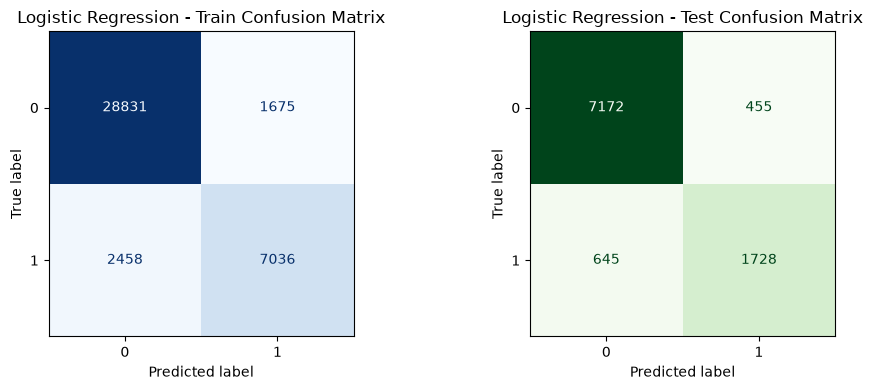

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 1. تجهيز البيانات وحذف الأعمدة غير الضرورية
df = pd.read_csv('startup.csv')
cols_to_drop = [
    'Startup_Failure_Flag',  # Target
    'Shutdown_Probability',  # Leakage
    'Shutdown_Risk',  # Leakage
    'Burnout_Level',  # تكرار
    'Founder_Burnout_Flag',  # تكرار
]

X = df.drop(columns=cols_to_drop)
y = df['Startup_Failure_Flag']

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# 2. معالجة البيانات
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)


# 3. دالة طباعة المقاييس للـ Train والـ Test معاً
def evaluate_train_test(name, model):
  # التدريب
  model.fit(X_train, y_train)

  # التنبؤات
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # الاحتمالات لـ ROC-AUC
  y_train_prob = (
      model.predict_proba(X_train)[:, 1]
      if hasattr(model, 'predict_proba')
      else None
  )
  y_test_prob = (
      model.predict_proba(X_test)[:, 1]
      if hasattr(model, 'predict_proba')
      else None
  )

  # تجميع المقاييس في جدول مقارنة
  metrics_dict = {
      'Metric': [
          'Accuracy',
          'Recall (Class 0 - Major)',
          'Recall (Class 1 - Minor)',
          'Precision (Class 1 - Minor)',
          'F1-Score (Class 1 - Minor)',
          'ROC-AUC',
      ],
      'Train': [
          accuracy_score(y_train, y_train_pred),
          recall_score(y_train, y_train_pred, pos_label=0),
          recall_score(y_train, y_train_pred, pos_label=1),
          precision_score(
              y_train, y_train_pred, pos_label=1, zero_division=0
          ),
          f1_score(y_train, y_train_pred, pos_label=1, zero_division=0),
          roc_auc_score(y_train, y_train_prob)
          if y_train_prob is not None
          else np.nan,
      ],
      'Test': [
          accuracy_score(y_test, y_test_pred),
          recall_score(y_test, y_test_pred, pos_label=0),
          recall_score(y_test, y_test_pred, pos_label=1),
          precision_score(y_test, y_test_pred, pos_label=1, zero_division=0),
          f1_score(y_test, y_test_pred, pos_label=1, zero_division=0),
          roc_auc_score(y_test, y_test_prob)
          if y_test_prob is not None
          else np.nan,
      ],
  }

  print(f"\n{'='*30} MODEL: {name} {'='*30}")
  df_res = pd.DataFrame(metrics_dict)
  display(df_res.style.format({'Train': '{:.4f}', 'Test': '{:.4f}'}))

  # تقارير التصنيف
  print(f'\n--- Classification Report (TRAIN SET) ---')
  print(
      classification_report(
          y_train,
          y_train_pred,
          target_names=['Class 0 (Major)', 'Class 1 (Minor)'],
          digits=4,
      )
  )

  print(f'--- Classification Report (TEST SET) ---')
  print(
      classification_report(
          y_test,
          y_test_pred,
          target_names=['Class 0 (Major)', 'Class 1 (Minor)'],
          digits=4,
      )
  )

  # رسم مصفوفات الارتباك (Train و Test)
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))
  ConfusionMatrixDisplay.from_predictions(
      y_train, y_train_pred, ax=axes[0], cmap='Blues', colorbar=False
  )
  axes[0].set_title(f'{name} - Train Confusion Matrix')
  axes[0].grid(False)

  ConfusionMatrixDisplay.from_predictions(
      y_test, y_test_pred, ax=axes[1], cmap='Greens', colorbar=False
  )
  axes[1].set_title(f'{name} - Test Confusion Matrix')
  axes[1].grid(False)

  plt.tight_layout()
  plt.show()
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
evaluate_train_test('Logistic Regression', log_reg)


============================== MODEL: Decision Tree ==============================


,Metric,Train,Test
0,Accuracy,0.8759,0.8646
1,Recall (Class 0 - Major),0.9347,0.9271
2,Recall (Class 1 - Minor),0.6870,0.6637
3,Precision (Class 1 - Minor),0.7661,0.7391
4,F1-Score (Class 1 - Minor),0.7244,0.6994
5,ROC-AUC,0.9219,0.9093



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9056    0.9347    0.9199     30506
Class 1 (Minor)     0.7661    0.6870    0.7244      9494

       accuracy                         0.8759     40000
      macro avg     0.8359    0.8108    0.8222     40000
   weighted avg     0.8725    0.8759    0.8735     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.8986    0.9271    0.9126      7627
Class 1 (Minor)     0.7391    0.6637    0.6994      2373

       accuracy                         0.8646     10000
      macro avg     0.8188    0.7954    0.8060     10000
   weighted avg     0.8607    0.8646    0.8620     10000



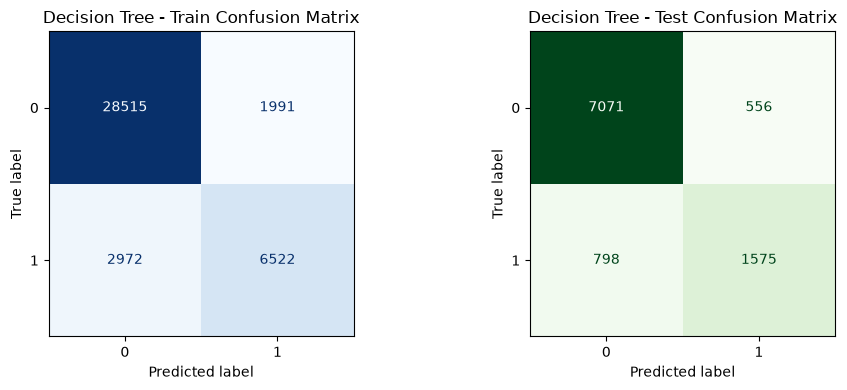

In [50]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
evaluate_train_test('Decision Tree', dt_model)


============================== MODEL: Random Forest ==============================


,Metric,Train,Test
0,Accuracy,0.9210,0.8815
1,Recall (Class 0 - Major),0.9786,0.9569
2,Recall (Class 1 - Minor),0.7357,0.6393
3,Precision (Class 1 - Minor),0.9145,0.8218
4,F1-Score (Class 1 - Minor),0.8154,0.7191
5,ROC-AUC,0.9739,0.9388



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9225    0.9786    0.9497     30506
Class 1 (Minor)     0.9145    0.7357    0.8154      9494

       accuracy                         0.9210     40000
      macro avg     0.9185    0.8572    0.8826     40000
   weighted avg     0.9206    0.9210    0.9178     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.8950    0.9569    0.9249      7627
Class 1 (Minor)     0.8218    0.6393    0.7191      2373

       accuracy                         0.8815     10000
      macro avg     0.8584    0.7981    0.8220     10000
   weighted avg     0.8776    0.8815    0.8761     10000



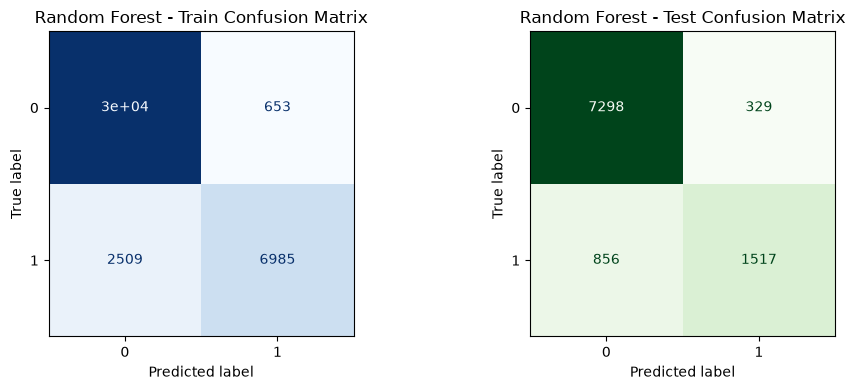

In [51]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42
)
evaluate_train_test('Random Forest', rf_model)


============================== MODEL: Gradient Boosting ==============================


,Metric,Train,Test
0,Accuracy,0.8994,0.8916
1,Recall (Class 0 - Major),0.9505,0.9444
2,Recall (Class 1 - Minor),0.7354,0.7219
3,Precision (Class 1 - Minor),0.8222,0.8016
4,F1-Score (Class 1 - Minor),0.7764,0.7596
5,ROC-AUC,0.9551,0.9477



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9203    0.9505    0.9351     30506
Class 1 (Minor)     0.8222    0.7354    0.7764      9494

       accuracy                         0.8994     40000
      macro avg     0.8712    0.8430    0.8558     40000
   weighted avg     0.8970    0.8994    0.8975     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9161    0.9444    0.9300      7627
Class 1 (Minor)     0.8016    0.7219    0.7596      2373

       accuracy                         0.8916     10000
      macro avg     0.8588    0.8331    0.8448     10000
   weighted avg     0.8889    0.8916    0.8896     10000



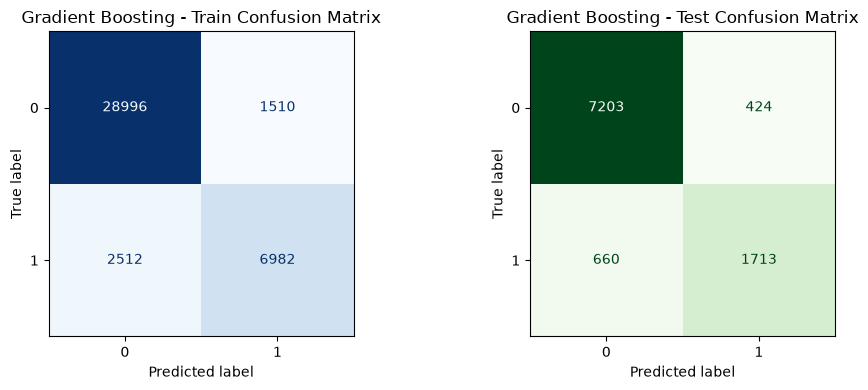

In [52]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
evaluate_train_test('Gradient Boosting', gb_model)


============================== MODEL: AdaBoost ==============================


,Metric,Train,Test
0,Accuracy,0.8925,0.8890
1,Recall (Class 0 - Major),0.9437,0.9388
2,Recall (Class 1 - Minor),0.7279,0.7290
3,Precision (Class 1 - Minor),0.8009,0.7874
4,F1-Score (Class 1 - Minor),0.7627,0.7571
5,ROC-AUC,0.9495,0.9454



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9177    0.9437    0.9305     30506
Class 1 (Minor)     0.8009    0.7279    0.7627      9494

       accuracy                         0.8925     40000
      macro avg     0.8593    0.8358    0.8466     40000
   weighted avg     0.8900    0.8925    0.8907     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9176    0.9388    0.9281      7627
Class 1 (Minor)     0.7874    0.7290    0.7571      2373

       accuracy                         0.8890     10000
      macro avg     0.8525    0.8339    0.8426     10000
   weighted avg     0.8867    0.8890    0.8875     10000



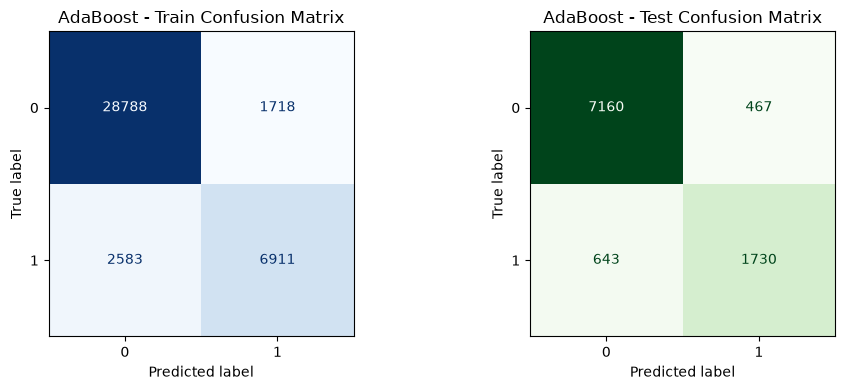

In [53]:
ada_model = AdaBoostClassifier(
    n_estimators=100, learning_rate=1.0, random_state=42
)
evaluate_train_test('AdaBoost', ada_model)


============================== MODEL: XGBoost ==============================


,Metric,Train,Test
0,Accuracy,0.9569,0.8851
1,Recall (Class 0 - Major),0.9784,0.9334
2,Recall (Class 1 - Minor),0.8877,0.7299
3,Precision (Class 1 - Minor),0.9276,0.7732
4,F1-Score (Class 1 - Minor),0.9072,0.7509
5,ROC-AUC,0.9909,0.9429



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9655    0.9784    0.9719     30506
Class 1 (Minor)     0.9276    0.8877    0.9072      9494

       accuracy                         0.9569     40000
      macro avg     0.9465    0.9331    0.9396     40000
   weighted avg     0.9565    0.9569    0.9566     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9174    0.9334    0.9253      7627
Class 1 (Minor)     0.7732    0.7299    0.7509      2373

       accuracy                         0.8851     10000
      macro avg     0.8453    0.8316    0.8381     10000
   weighted avg     0.8832    0.8851    0.8839     10000



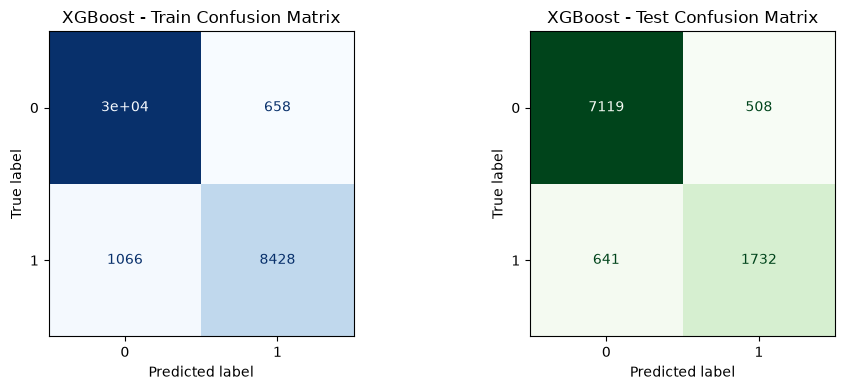

In [54]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
evaluate_train_test('XGBoost', xgb_model)


============================== MODEL: K-Nearest Neighbors ==============================


,Metric,Train,Test
0,Accuracy,0.9010,0.8573
1,Recall (Class 0 - Major),0.9610,0.9330
2,Recall (Class 1 - Minor),0.7082,0.6140
3,Precision (Class 1 - Minor),0.8495,0.7403
4,F1-Score (Class 1 - Minor),0.7725,0.6713
5,ROC-AUC,0.9570,0.8822



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9137    0.9610    0.9367     30506
Class 1 (Minor)     0.8495    0.7082    0.7725      9494

       accuracy                         0.9010     40000
      macro avg     0.8816    0.8346    0.8546     40000
   weighted avg     0.8984    0.9010    0.8977     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.8860    0.9330    0.9089      7627
Class 1 (Minor)     0.7403    0.6140    0.6713      2373

       accuracy                         0.8573     10000
      macro avg     0.8132    0.7735    0.7901     10000
   weighted avg     0.8514    0.8573    0.8525     10000



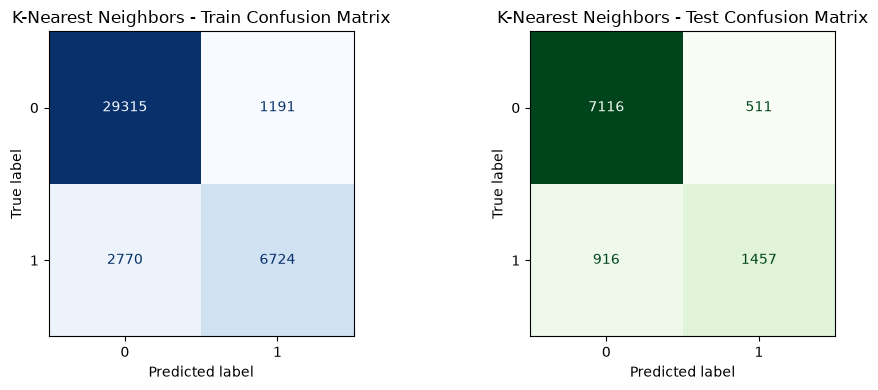

In [55]:
knn_model = KNeighborsClassifier(n_neighbors=5)
evaluate_train_test('K-Nearest Neighbors', knn_model)



============================== MODEL: Neural Network (MLP) ==============================


,Metric,Train,Test
0,Accuracy,0.8971,0.8880
1,Recall (Class 0 - Major),0.9397,0.9322
2,Recall (Class 1 - Minor),0.7603,0.7459
3,Precision (Class 1 - Minor),0.7969,0.7739
4,F1-Score (Class 1 - Minor),0.7781,0.7597
5,ROC-AUC,0.9541,0.9482



--- Classification Report (TRAIN SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9264    0.9397    0.9330     30506
Class 1 (Minor)     0.7969    0.7603    0.7781      9494

       accuracy                         0.8971     40000
      macro avg     0.8617    0.8500    0.8556     40000
   weighted avg     0.8957    0.8971    0.8963     40000

--- Classification Report (TEST SET) ---
                 precision    recall  f1-score   support

Class 0 (Major)     0.9218    0.9322    0.9270      7627
Class 1 (Minor)     0.7739    0.7459    0.7597      2373

       accuracy                         0.8880     10000
      macro avg     0.8479    0.8391    0.8433     10000
   weighted avg     0.8867    0.8880    0.8873     10000



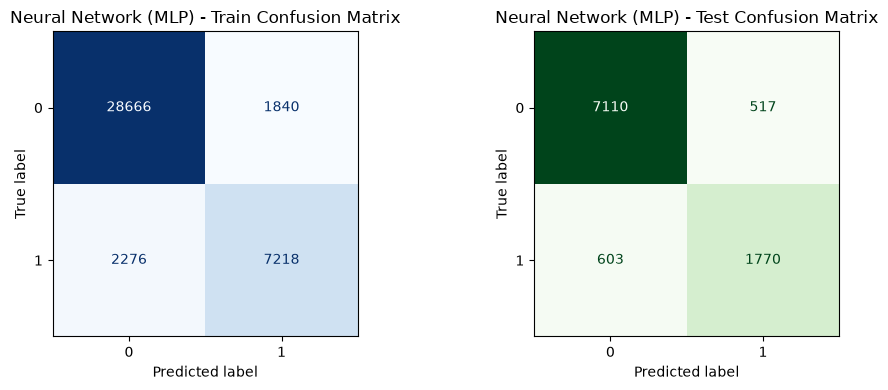

In [56]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    random_state=42,
)
evaluate_train_test('Neural Network (MLP)', mlp_model)